In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv(
    "AirPassengers.csv",
    parse_dates=['Month'],
    index_col='Month'
)

In [4]:
print(df.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


In [5]:

print(df.columns)



Index(['#Passengers'], dtype='object')


In [30]:
df.rename(columns={'Passengers':'Passengers'}, inplace=True)



In [7]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


**Resampling**

In [8]:
quarterly = df.resample('Q').mean()

print(quarterly.head())

            Passengers
Month                 
1949-03-31  120.666667
1949-06-30  128.333333
1949-09-30  144.000000
1949-12-31  113.666667
1950-03-31  127.333333


/tmp/ipykernel_1872/3397247166.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df.resample('Q').mean()


**PLOT**

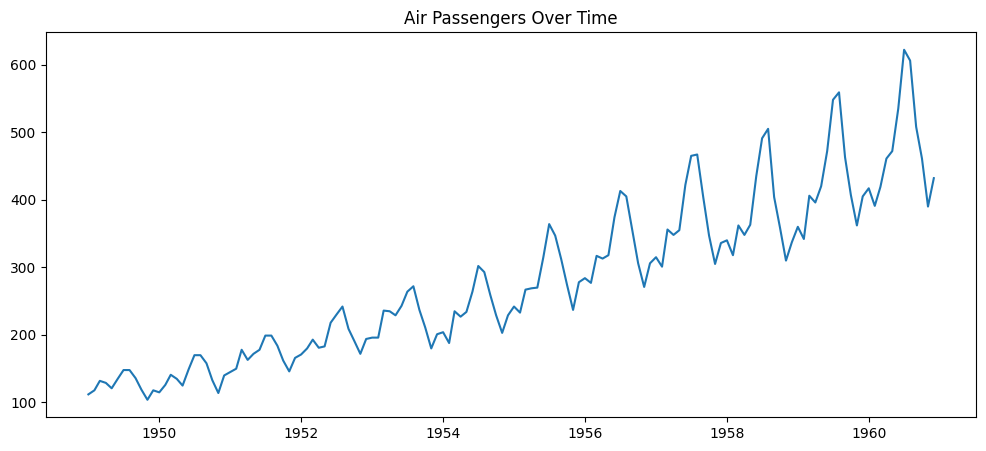

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df)
plt.title("Air Passengers Over Time")
plt.show()

In [11]:
quarterly = df.resample('Q').mean()

quarterly.head()

/tmp/ipykernel_1872/3230405034.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df.resample('Q').mean()


,Passengers
Month,
1949-03-31,120.666667
1949-06-30,128.333333
1949-09-30,144.000000
1949-12-31,113.666667
1950-03-31,127.333333


**Trend & Seasonality**

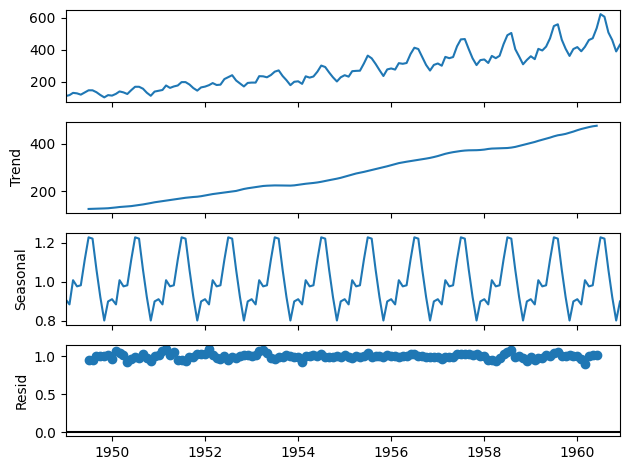

In [12]:
decomposition = seasonal_decompose(
    df,
    model='multiplicative'
)

decomposition.plot()
plt.show()

In [15]:
df['MA_6'] = df['Passengers'].rolling(6).mean()

In [16]:
df.head(10)

,Passengers,MA_6
Month,,
1949-01-01,112,NaN
1949-02-01,118,NaN
1949-03-01,132,NaN
1949-04-01,129,NaN
1949-05-01,121,NaN
1949-06-01,135,124.500000
1949-07-01,148,130.500000
1949-08-01,148,135.500000
1949-09-01,136,136.166667


In [17]:
df['MA_12'] = df['Passengers'].rolling(12).mean()

In [18]:
df.head(12)

,Passengers,MA_6,MA_12
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN
1949-06-01,135,124.500000,NaN
1949-07-01,148,130.500000,NaN
1949-08-01,148,135.500000,NaN
1949-09-01,136,136.166667,NaN


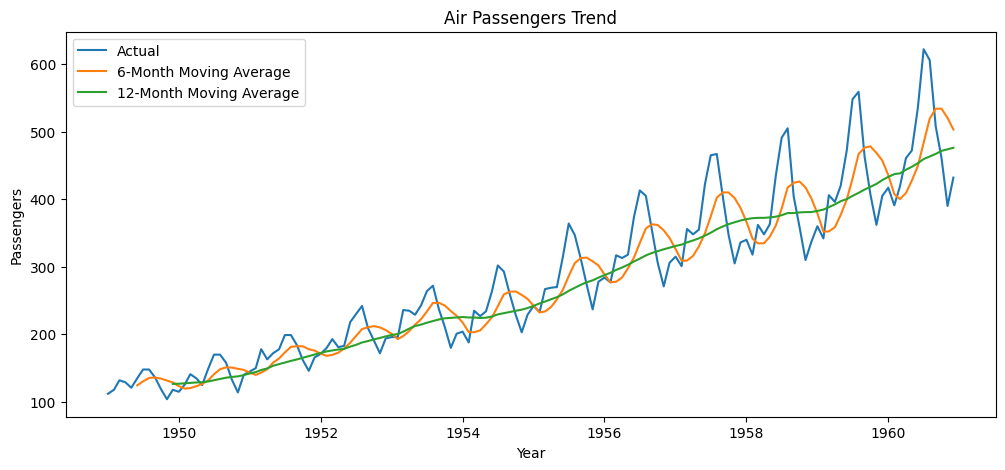

In [19]:
plt.figure(figsize=(12,5))

plt.plot(df['Passengers'], label='Actual')
plt.plot(df['MA_6'], label='6-Month Moving Average')
plt.plot(df['MA_12'], label='12-Month Moving Average')

plt.title('Air Passengers Trend')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()

plt.show()

In [22]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (132, 3)
Test Shape: (12, 3)


**ARIMA Model**

In [23]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Passengers'], order=(2,1,1))

result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -619.131
Date:                Thu, 18 Jun 2026   AIC                           1246.262
Time:                        15:19:35   BIC                           1257.763
Sample:                    01-01-1949   HQIC                          1250.936
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0698      0.094     11.323      0.000       0.885       1.255
ar.L2         -0.4734      0.101     -4.670      0.000      -0.672      -0.275
ma.L1         -0.8402      0.085     -9.851      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [24]:
forecast = result.forecast(steps=12)

print(forecast)

1960-01-01    437.013051
1960-02-01    450.903711
1960-03-01    450.608213
1960-04-01    443.715784
1960-05-01    436.482007
1960-06-01    432.006253
1960-07-01    430.642700
1960-08-01    431.302911
1960-09-01    432.654770
1960-10-01    433.788454
1960-11-01    434.361280
1960-12-01    434.437378
Freq: MS, Name: predicted_mean, dtype: float64


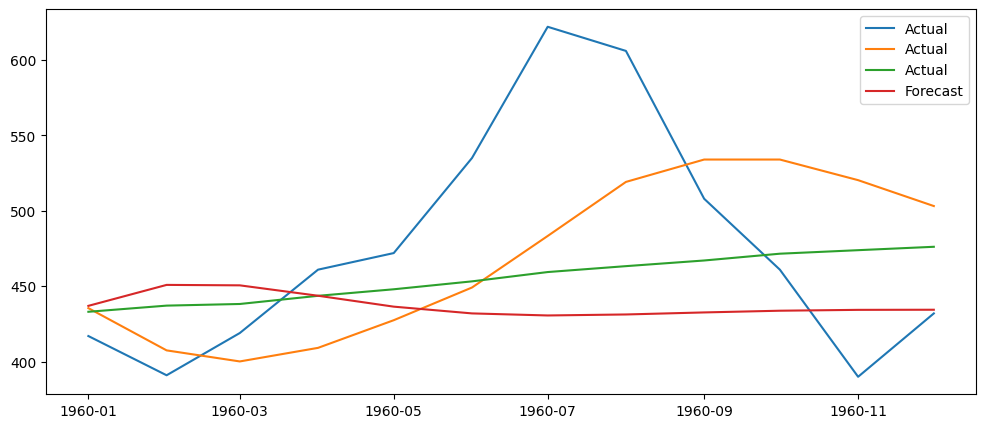

In [26]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Actual')

plt.plot(forecast, label='Forecast')

plt.legend()

plt.show()

In [28]:
print(test.shape)
print(forecast.shape)

print(test.columns)

(12, 3)
(12,)
Index(['Passengers', 'MA_6', 'MA_12'], dtype='object')


**RMSE**

In [29]:
rmse = np.sqrt(
    mean_squared_error(
        test['Passengers'],
        forecast
    )
)

print("RMSE:", rmse)

RMSE: 87.8843772301304


In [31]:
forecast = result.forecast(
    steps=12
)

**Compare Actual vs Predicted**

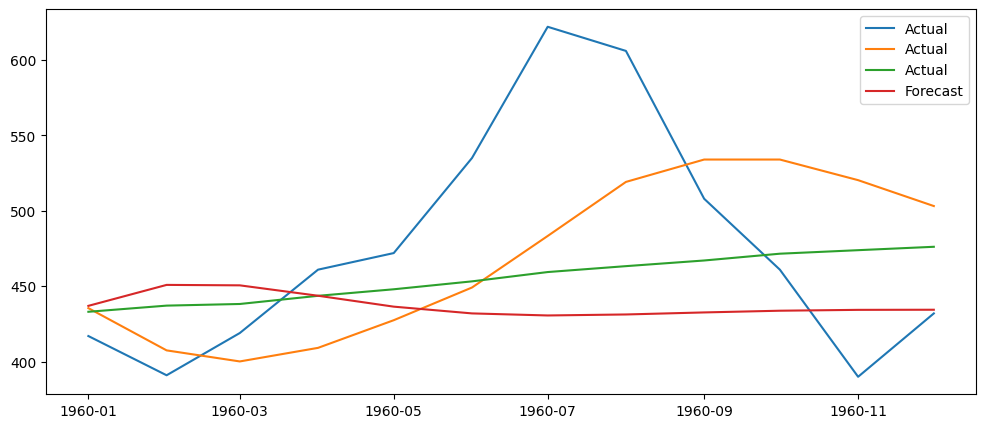

In [32]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Actual')

plt.plot(forecast, label='Forecast')

plt.legend()

plt.show()

**Actual vs Forecast Plot**

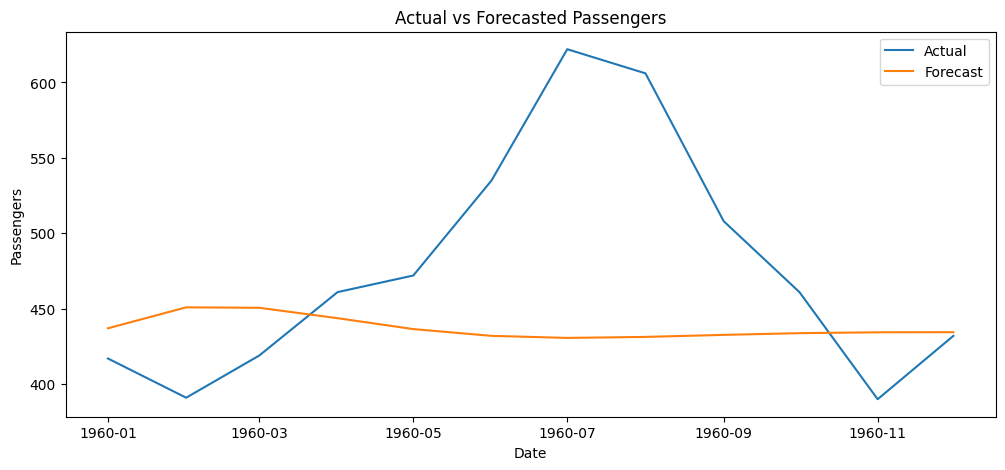

In [33]:
plt.figure(figsize=(12,5))

plt.plot(test['Passengers'], label='Actual')
plt.plot(forecast, label='Forecast')

plt.title('Actual vs Forecasted Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()

plt.show()

**Forecast Error**

In [34]:
error = test['Passengers'] - forecast

print(error.head())

Month
1960-01-01   -20.013051
1960-02-01   -59.903711
1960-03-01   -31.608213
1960-04-01    17.284216
1960-05-01    35.517993
dtype: float64


**Mean Absolute Error (MAE)**

In [35]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test['Passengers'],
    forecast
)

print("MAE:", mae)

MAE: 65.2275629104314


**Passenger Growth Rate**

In [36]:
growth_rate = (
    (df['Passengers'].iloc[-1] -
     df['Passengers'].iloc[0])
    /
    df['Passengers'].iloc[0]
) * 100

print("Growth Rate:", growth_rate,"%")

Growth Rate: 285.7142857142857 %


**Monthly Trend Analysis**

In [37]:
monthly_avg = df.groupby(df.index.month)['Passengers'].mean()

print(monthly_avg)

Month
1     241.750000
2     235.000000
3     270.166667
4     267.083333
5     271.833333
6     311.666667
7     351.333333
8     351.083333
9     302.416667
10    266.583333
11    232.833333
12    261.833333
Name: Passengers, dtype: float64


**Best and Worst Month**

In [38]:
monthly_avg = df.groupby(df.index.month)['Passengers'].mean()

print("Highest Month:")
print(monthly_avg.idxmax())

print("Lowest Month:")
print(monthly_avg.idxmin())

Highest Month:
7
Lowest Month:
11


**Future 12-Month Forecast Plot**

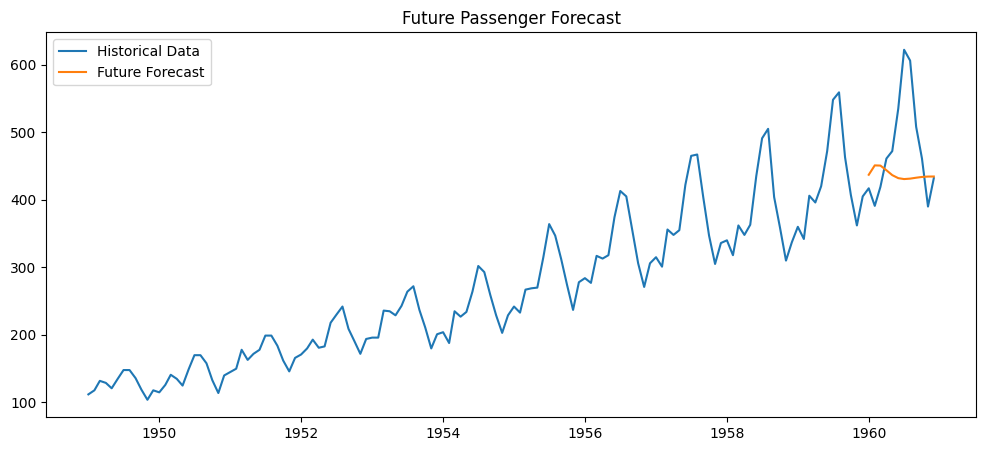

In [39]:
future_forecast = result.forecast(steps=12)

plt.figure(figsize=(12,5))

plt.plot(df['Passengers'], label='Historical Data')
plt.plot(
    future_forecast,
    label='Future Forecast'
)

plt.legend()
plt.title('Future Passenger Forecast')
plt.show()

**ACF & PACF Plot**

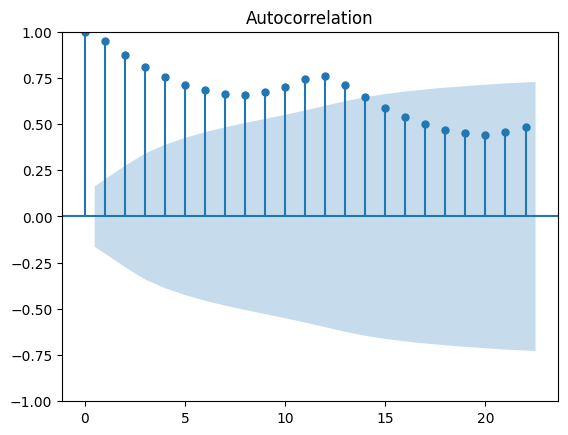

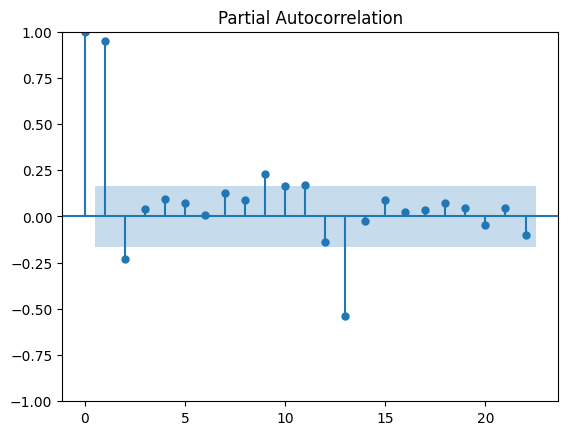

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Passengers'])
plt.show()

plot_pacf(df['Passengers'])
plt.show()

**Year-wise Passenger Growth**

/tmp/ipykernel_1872/2027145699.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['Passengers'].resample('Y').mean()


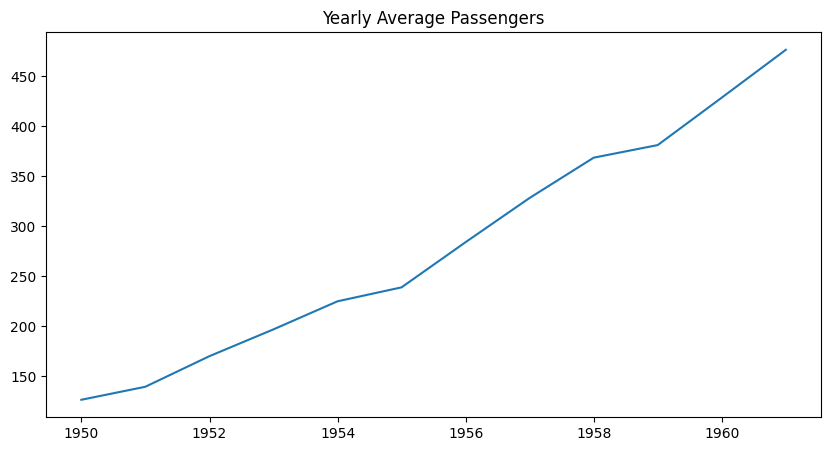

In [41]:
yearly = df['Passengers'].resample('Y').mean()

plt.figure(figsize=(10,5))
plt.plot(yearly)
plt.title("Yearly Average Passengers")
plt.show()

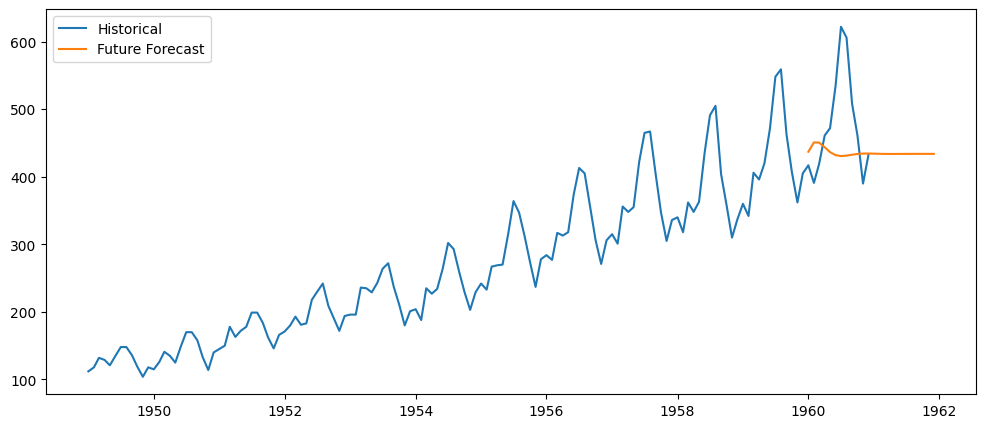

In [43]:
future_forecast = result.forecast(steps=24)

plt.figure(figsize=(12,5))
plt.plot(df['Passengers'], label='Historical')
plt.plot(future_forecast, label='Future Forecast')
plt.legend()
plt.show()

In [45]:
df.to_csv("cleaned_passengers.csv", index=False)

print("\nCleaned dataset saved as 'cleaned_customers.csv'")


Cleaned dataset saved as 'cleaned_customers.csv'
